# Métodos y Modelos Cuantitativos
## Sesión 2 — Modelos de Transporte y Asignación

En este Notebook aplicaremos Python para resolver problemas de transporte y asignación.

Trabajaremos con los casos analizados previamente en clase para pasar de la formulación matemática a su solución computacional, visualizar los resultados y experimentar con diferentes escenarios.

## Librerías

Utilizaremos `NumPy` y `Pandas` para representar los datos, `SciPy` para resolver los modelos de optimización, `Matplotlib` para las gráficas y `NetworkX` para representar las redes.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from scipy.optimize import linprog
from scipy.optimize import linear_sum_assignment

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## Representación de una red logística

Antes de resolver el problema de transporte construiremos una pequeña red para observar cómo los nodos, conexiones y costos estudiados en clase pueden representarse mediante Python.

In [3]:
G = nx.DiGraph()

G.add_edge("Planta 1", "CEDIS A", costo=10)
G.add_edge("Planta 1", "CEDIS B", costo=15)
G.add_edge("Planta 2", "CEDIS A", costo=12)
G.add_edge("Planta 2", "CEDIS B", costo=8)

print("Nodos:")
print(list(G.nodes()))

print("\nConexiones:")
print(list(G.edges(data=True)))

Nodos:
['Planta 1', 'CEDIS A', 'CEDIS B', 'Planta 2']

Conexiones:
[('Planta 1', 'CEDIS A', {'costo': 10}), ('Planta 1', 'CEDIS B', {'costo': 15}), ('Planta 2', 'CEDIS A', {'costo': 12}), ('Planta 2', 'CEDIS B', {'costo': 8})]


La representación describe la estructura de la red, pero todavía no determina cuánto producto debe transportarse por cada conexión.

Para determinar los flujos utilizaremos un modelo de transporte.

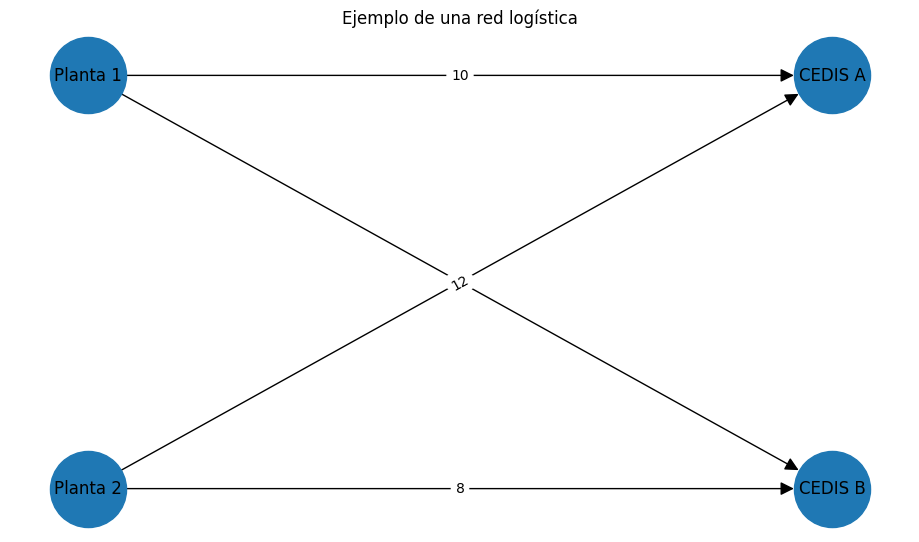

In [4]:
pos = {
    "Planta 1": (0, 1),
    "Planta 2": (0, 0),
    "CEDIS A": (2, 1),
    "CEDIS B": (2, 0)
}

plt.figure(figsize=(9, 5))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    arrows=True,
    arrowsize=20
)

costos_red = nx.get_edge_attributes(G, "costo")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=costos_red
)

plt.title("Ejemplo de una red logística")
plt.show()

# Modelo de Transporte

Utilizaremos el caso **Red de Distribución Bajío** analizado en clase.

Primero representaremos en Python los costos de transporte, la oferta disponible en cada planta y la demanda requerida en cada CEDIS.

In [5]:
origenes = [
    "León",
    "Querétaro",
    "San Luis Potosí"
]

destinos = [
    "Guadalajara",
    "CDMX",
    "Monterrey"
]

costos = np.array([
    [10, 15, 20],
    [12,  8, 18],
    [16, 12, 10]
], dtype=float)

oferta = np.array([400, 500, 300], dtype=float)

demanda = np.array([300, 500, 400], dtype=float)

print("Datos cargados correctamente.")

Datos cargados correctamente.


## Matriz de costos

Convertiremos los datos en un `DataFrame` para facilitar su visualización.

Las filas representan los orígenes y las columnas los destinos.

In [6]:
df_costos = pd.DataFrame(
    costos,
    index=origenes,
    columns=destinos
)

df_costos

,Guadalajara,CDMX,Monterrey
León,10.0,15.0,20.0
Querétaro,12.0,8.0,18.0
San Luis Potosí,16.0,12.0,10.0


## Verificación del problema

Antes de resolver el modelo verificaremos que la oferta total sea igual a la demanda total.

In [7]:
oferta_total = oferta.sum()
demanda_total = demanda.sum()

print(f"Oferta total: {oferta_total:.0f} toneladas")
print(f"Demanda total: {demanda_total:.0f} toneladas")

if np.isclose(oferta_total, demanda_total):
    print("El problema está BALANCEADO.")
else:
    print("El problema NO está balanceado.")

Oferta total: 1200 toneladas
Demanda total: 1200 toneladas
El problema está BALANCEADO.


## Representación computacional del modelo

Ahora convertiremos la formulación matemática estudiada en clase en los vectores y matrices que necesita `linprog()`.

Primero convertiremos la matriz de costos en un vector.

In [8]:
c = costos.flatten()

print("Vector de costos:")
print(c)

Vector de costos:
[10. 15. 20. 12.  8. 18. 16. 12. 10.]


## Restricciones

Construiremos las restricciones correspondientes a la oferta de cada planta y la demanda de cada CEDIS.

Como el problema está balanceado, toda la oferta será distribuida y toda la demanda deberá ser satisfecha.

In [9]:
m = len(origenes)
n = len(destinos)

A_eq = []
b_eq = []

# Restricciones de oferta
for i in range(m):
    fila = np.zeros(m * n)

    for j in range(n):
        fila[i * n + j] = 1

    A_eq.append(fila)
    b_eq.append(oferta[i])

# Restricciones de demanda
for j in range(n):
    fila = np.zeros(m * n)

    for i in range(m):
        fila[i * n + j] = 1

    A_eq.append(fila)
    b_eq.append(demanda[j])

A_eq = np.array(A_eq)
b_eq = np.array(b_eq)

print("Matriz de restricciones:")
print(A_eq)

print("\nVector del lado derecho:")
print(b_eq)

Matriz de restricciones:
[[1. 1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1.]
 [1. 0. 0. 1. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 1. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 1. 0. 0. 1.]]

Vector del lado derecho:
[400. 500. 300. 300. 500. 400.]


## Solución del modelo

Con la función objetivo y las restricciones definidas podemos ejecutar el Solver para determinar el plan de distribución de menor costo.

In [10]:
resultado = linprog(
    c=c,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=[(0, None)] * (m * n),
    method="highs"
)

print("¿Se encontró solución?", resultado.success)
print(resultado.message)

¿Se encontró solución? True
Optimization terminated successfully. (HiGHS Status 7: Optimal)


In [12]:
if resultado.success:

    solucion = resultado.x.reshape(m, n)

    df_solucion = pd.DataFrame(
        solucion,
        index=origenes,
        columns=destinos
    )

    print(f"Costo mínimo total: ${resultado.fun:,.2f}")

    display(df_solucion)

else:
    print("No fue posible encontrar una solución.")

Costo mínimo total: $12,000.00


,Guadalajara,CDMX,Monterrey
León,300.0,0.0,100.0
Querétaro,0.0,500.0,-0.0
San Luis Potosí,0.0,0.0,300.0


## Interpretación 

###  Rutas utilizadas

Para facilitar la interpretación mostraremos únicamente las rutas que transportan mercancía y calcularemos su costo correspondiente.

In [14]:
detalle = []

for i, origen in enumerate(origenes):
    for j, destino in enumerate(destinos):

        toneladas = solucion[i, j]

        if toneladas > 1e-6:

            costo_unitario = costos[i, j]
            costo_ruta = toneladas * costo_unitario

            detalle.append({
                "Origen": origen,
                "Destino": destino,
                "Toneladas": toneladas,
                "Costo unitario": costo_unitario,
                "Costo de la ruta": costo_ruta
            })

df_detalle = pd.DataFrame(detalle)

df_detalle

,Origen,Destino,Toneladas,Costo unitario,Costo de la ruta
0,León,Guadalajara,300.0,10.0,3000.0
1,León,Monterrey,100.0,20.0,2000.0
2,Querétaro,CDMX,500.0,8.0,4000.0
3,San Luis Potosí,Monterrey,300.0,10.0,3000.0


In [15]:
print(
    f"Costo total: "
    f"${df_detalle['Costo de la ruta'].sum():,.2f}"
)

Costo total: $12,000.00


In [16]:
G_optimo = nx.DiGraph()

for origen in origenes:
    G_optimo.add_node(origen)

for destino in destinos:
    G_optimo.add_node(destino)

for i, origen in enumerate(origenes):
    for j, destino in enumerate(destinos):

        toneladas = solucion[i, j]

        if toneladas > 1e-6:
            G_optimo.add_edge(
                origen,
                destino,
                toneladas=toneladas
            )

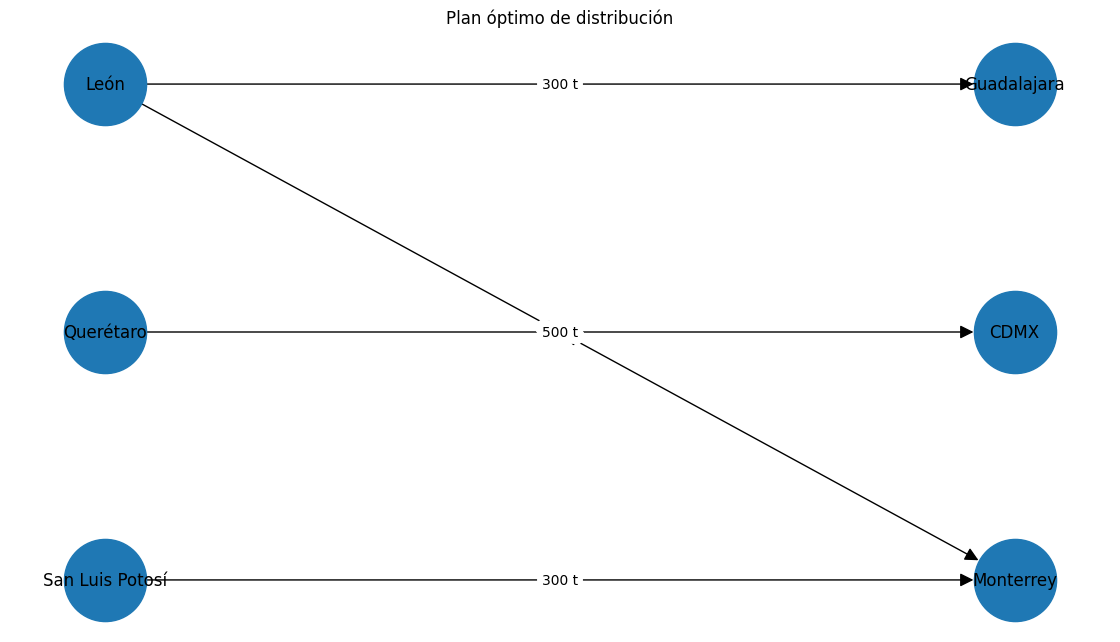

In [17]:
pos = {
    "León": (0, 2),
    "Querétaro": (0, 1),
    "San Luis Potosí": (0, 0),
    "Guadalajara": (3, 2),
    "CDMX": (3, 1),
    "Monterrey": (3, 0)
}

plt.figure(figsize=(11, 6))

nx.draw(
    G_optimo,
    pos,
    with_labels=True,
    node_size=3500,
    arrows=True,
    arrowsize=20
)

etiquetas = {
    (u, v): f"{datos['toneladas']:.0f} t"
    for u, v, datos in G_optimo.edges(data=True)
}

nx.draw_networkx_edge_labels(
    G_optimo,
    pos,
    edge_labels=etiquetas
)

plt.title("Plan óptimo de distribución")
plt.show()

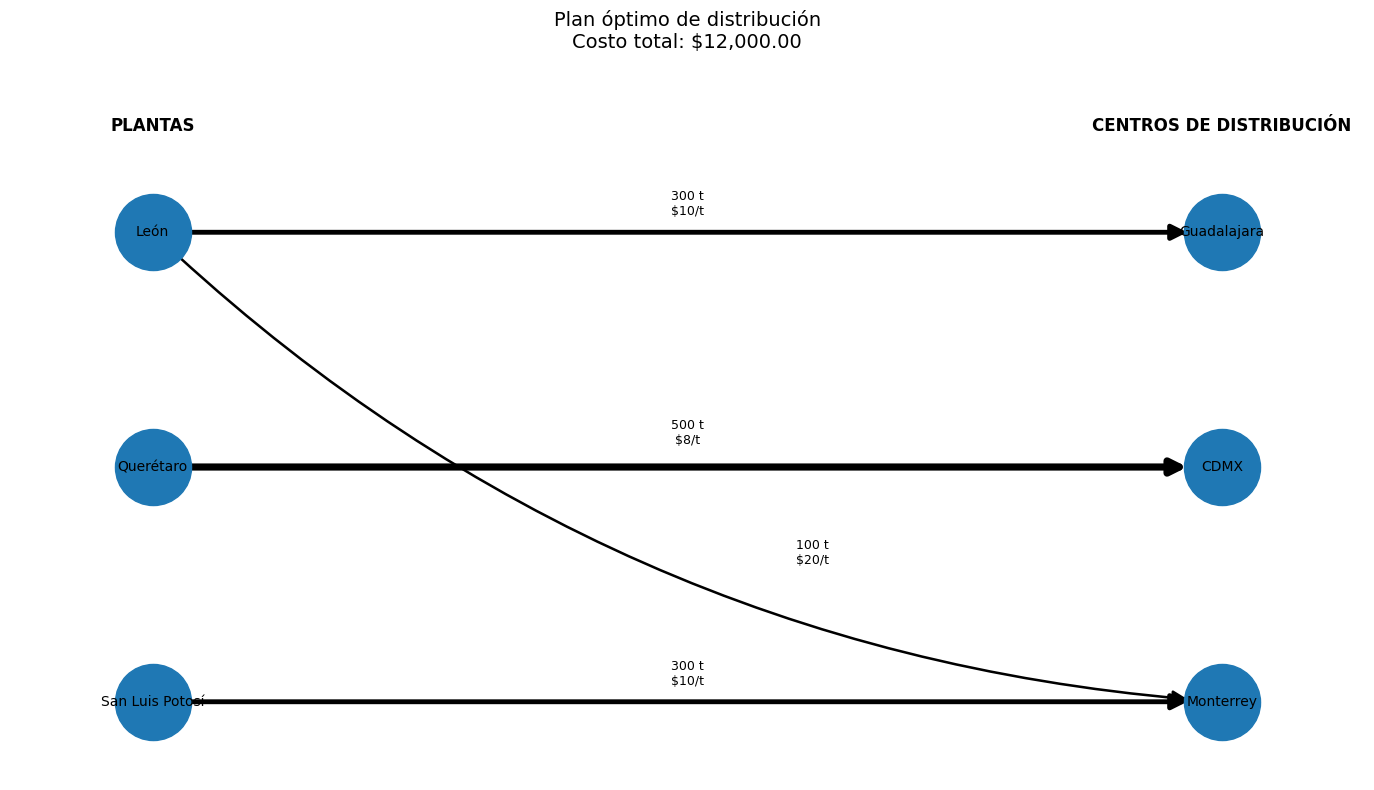

In [18]:
# -------------------------------------------------------
# VISUALIZACIÓN DEL PLAN ÓPTIMO DE DISTRIBUCIÓN
# -------------------------------------------------------

G_optimo = nx.DiGraph()

# Agregar nodos
for origen in origenes:
    G_optimo.add_node(origen)

for destino in destinos:
    G_optimo.add_node(destino)

# Agregar solamente rutas utilizadas
for i, origen in enumerate(origenes):
    for j, destino in enumerate(destinos):

        toneladas = solucion[i, j]

        if toneladas > 1e-6:

            G_optimo.add_edge(
                origen,
                destino,
                toneladas=toneladas,
                costo=costos[i, j]
            )


# -------------------------------------------------------
# POSICIONES
# -------------------------------------------------------

pos = {
    "León": (0, 3),
    "Querétaro": (0, 1.5),
    "San Luis Potosí": (0, 0),

    "Guadalajara": (6, 3),
    "CDMX": (6, 1.5),
    "Monterrey": (6, 0)
}


# -------------------------------------------------------
# FIGURA
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 8))


# -------------------------------------------------------
# NODOS
# -------------------------------------------------------

nx.draw_networkx_nodes(
    G_optimo,
    pos,
    node_size=3000,
    ax=ax
)

nx.draw_networkx_labels(
    G_optimo,
    pos,
    font_size=10,
    ax=ax
)


# -------------------------------------------------------
# DIBUJAR CADA RUTA POR SEPARADO
# -------------------------------------------------------

for origen, destino, datos in G_optimo.edges(data=True):

    toneladas = datos["toneladas"]

    # Grosor proporcional al flujo
    ancho = 1 + toneladas / 120

    # Curvar únicamente León -> Monterrey
    if origen == "León" and destino == "Monterrey":
        curvatura = 0.18
    else:
        curvatura = 0

    nx.draw_networkx_edges(
        G_optimo,
        pos,
        edgelist=[(origen, destino)],
        width=ancho,
        arrows=True,
        arrowsize=22,
        arrowstyle="-|>",
        connectionstyle=f"arc3,rad={curvatura}",
        min_source_margin=25,
        min_target_margin=25,
        ax=ax
    )


# -------------------------------------------------------
# ETIQUETAS MANUALES
# -------------------------------------------------------

etiquetas_posicion = {
    ("León", "Guadalajara"): (3, 3.18),
    ("León", "Monterrey"): (3.7, 0.95),
    ("Querétaro", "CDMX"): (3, 1.72),
    ("San Luis Potosí", "Monterrey"): (3, 0.18)
}


for origen, destino, datos in G_optimo.edges(data=True):

    if (origen, destino) in etiquetas_posicion:

        x, y = etiquetas_posicion[(origen, destino)]

        texto = (
            f"{datos['toneladas']:.0f} t\n"
            f"${datos['costo']:.0f}/t"
        )

        ax.text(
            x,
            y,
            texto,
            ha="center",
            va="center",
            fontsize=9,
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor="none",
                alpha=0.9
            )
        )


# -------------------------------------------------------
# ENCABEZADOS
# -------------------------------------------------------

ax.text(
    0,
    3.65,
    "PLANTAS",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

ax.text(
    6,
    3.65,
    "CENTROS DE DISTRIBUCIÓN",
    ha="center",
    fontsize=12,
    fontweight="bold"
)


# -------------------------------------------------------
# TÍTULO
# -------------------------------------------------------

ax.set_title(
    f"Plan óptimo de distribución\n"
    f"Costo total: ${resultado.fun:,.2f}",
    fontsize=14,
    pad=20
)


# -------------------------------------------------------
# LÍMITES DE LA GRÁFICA
# -------------------------------------------------------

ax.set_xlim(-0.8, 6.8)
ax.set_ylim(-0.5, 4.0)

ax.axis("off")

plt.tight_layout()

plt.show()

# Comparación con una solución inicial

Implementaremos el método de **Esquina Noroeste** para obtener una solución inicial y posteriormente compararemos su costo con la solución óptima encontrada por el Solver.

In [20]:
def esquina_noroeste(oferta, demanda):

    oferta_restante = oferta.copy().astype(float)
    demanda_restante = demanda.copy().astype(float)

    m = len(oferta_restante)
    n = len(demanda_restante)

    solucion = np.zeros((m, n))

    i = 0
    j = 0

    while i < m and j < n:

        cantidad = min(
            oferta_restante[i],
            demanda_restante[j]
        )

        solucion[i, j] = cantidad

        oferta_restante[i] -= cantidad
        demanda_restante[j] -= cantidad

        oferta_agotada = np.isclose(
            oferta_restante[i], 0
        )

        demanda_satisfecha = np.isclose(
            demanda_restante[j], 0
        )

        if oferta_agotada and demanda_satisfecha:
            i += 1
            j += 1
        elif oferta_agotada:
            i += 1
        elif demanda_satisfecha:
            j += 1

    return solucion

In [21]:
solucion_noroeste = esquina_noroeste(
    oferta,
    demanda
)

df_noroeste = pd.DataFrame(
    solucion_noroeste,
    index=origenes,
    columns=destinos
)

df_noroeste

,Guadalajara,CDMX,Monterrey
León,300.0,100.0,0.0
Querétaro,0.0,400.0,100.0
San Luis Potosí,0.0,0.0,300.0


## Comparación de resultados

Calcularemos la diferencia entre ambas soluciones para determinar el ahorro obtenido mediante la optimización.

In [22]:
costo_noroeste = np.sum(
    solucion_noroeste * costos
)

costo_optimo = resultado.fun

ahorro = costo_noroeste - costo_optimo

porcentaje_ahorro = (
    ahorro / costo_noroeste
) * 100

print(
    f"Costo Esquina Noroeste: "
    f"${costo_noroeste:,.2f}"
)

print(
    f"Costo óptimo: "
    f"${costo_optimo:,.2f}"
)

print(
    f"Ahorro: "
    f"${ahorro:,.2f}"
)

print(
    f"Reducción del costo: "
    f"{porcentaje_ahorro:.2f}%"
)

Costo Esquina Noroeste: $12,500.00
Costo óptimo: $12,000.00
Ahorro: $500.00
Reducción del costo: 4.00%


## Automatizando

In [23]:
def resolver_transporte(costos, oferta, demanda):

    costos = np.asarray(costos, dtype=float)
    oferta = np.asarray(oferta, dtype=float)
    demanda = np.asarray(demanda, dtype=float)

    m, n = costos.shape

    if not np.isclose(oferta.sum(), demanda.sum()):
        raise ValueError(
            "Este ejemplo requiere que la oferta total "
            "sea igual a la demanda total."
        )

    c = costos.flatten()

    A_eq = []
    b_eq = []

    # Oferta
    for i in range(m):

        fila = np.zeros(m * n)

        for j in range(n):
            fila[i * n + j] = 1

        A_eq.append(fila)
        b_eq.append(oferta[i])

    # Demanda
    for j in range(n):

        fila = np.zeros(m * n)

        for i in range(m):
            fila[i * n + j] = 1

        A_eq.append(fila)
        b_eq.append(demanda[j])

    resultado = linprog(
        c=c,
        A_eq=np.array(A_eq),
        b_eq=np.array(b_eq),
        bounds=[(0, None)] * (m * n),
        method="highs"
    )

    return resultado

### Nuevo escenario

Mantendremos la demanda total de 1,200 toneladas, pero cambiaremos su distribución entre los CEDIS para observar cómo se modifica la solución.

In [27]:
nueva_demanda = np.array([
    400,
    400,
    400
], dtype=float)

resultado_escenario = resolver_transporte(
    costos,
    oferta,
    nueva_demanda
)

print(
    f"Costo original: "
    f"${resultado.fun:,.2f}"
)

print(
    f"Costo nuevo escenario: "
    f"${resultado_escenario.fun:,.2f}"
)

ValueError: Este ejemplo requiere que la oferta total sea igual a la demanda total.

In [26]:
solucion_escenario = resultado_escenario.x.reshape(
    len(origenes),
    len(destinos)
)

df_escenario = pd.DataFrame(
    solucion_escenario,
    index=origenes,
    columns=destinos
)

df_escenario

,Guadalajara,CDMX,Monterrey
León,300.0,0.0,100.0
Querétaro,0.0,400.0,100.0
San Luis Potosí,0.0,0.0,300.0


# Modelo de Asignación

Ahora utilizaremos el caso de asignación de operadores a puestos analizado en clase.

Representaremos los costos mediante una matriz y utilizaremos Python para encontrar la combinación de menor costo.

In [ ]:
operadores = [
    "Operador 1",
    "Operador 2",
    "Operador 3"
]

puestos = [
    "Lijado",
    "Pintura",
    "Insumos"
]

costos_asignacion = np.array([
    [10, 15,  9],
    [ 9, 18,  8],
    [12, 14, 10]
], dtype=float)

df_costos_asignacion = pd.DataFrame(
    costos_asignacion,
    index=operadores,
    columns=puestos
)

df_costos_asignacion

## Solución óptima

Utilizaremos `linear_sum_assignment()` para determinar qué operador debe asignarse a cada puesto.

In [ ]:
filas, columnas = linear_sum_assignment(
    costos_asignacion
)

asignaciones = []

for i, j in zip(filas, columnas):

    asignaciones.append({
        "Operador": operadores[i],
        "Puesto": puestos[j],
        "Costo": costos_asignacion[i, j]
    })

df_asignaciones = pd.DataFrame(asignaciones)

df_asignaciones

In [ ]:
costo_total_asignacion = df_asignaciones[
    "Costo"
].sum()

print(
    f"Costo mínimo total: "
    f"${costo_total_asignacion:,.2f}/hora"
)

## Visualización de la asignación

Finalmente representaremos las asignaciones seleccionadas mediante una red.

In [ ]:
G_asignacion = nx.Graph()

for operador in operadores:
    G_asignacion.add_node(operador)

for puesto in puestos:
    G_asignacion.add_node(puesto)

for _, fila in df_asignaciones.iterrows():

    G_asignacion.add_edge(
        fila["Operador"],
        fila["Puesto"],
        costo=fila["Costo"]
    )

pos = {
    "Operador 1": (0, 2),
    "Operador 2": (0, 1),
    "Operador 3": (0, 0),
    "Lijado": (3, 2),
    "Pintura": (3, 1),
    "Insumos": (3, 0)
}

plt.figure(figsize=(10, 6))

nx.draw(
    G_asignacion,
    pos,
    with_labels=True,
    node_size=3000
)

etiquetas = {
    (u, v): f"${datos['costo']:.0f}/h"
    for u, v, datos
    in G_asignacion.edges(data=True)
}

nx.draw_networkx_edge_labels(
    G_asignacion,
    pos,
    edge_labels=etiquetas
)

plt.title("Asignación óptima de operadores")
plt.show()

# Ejercicio

Una empresa cuenta con tres almacenes que abastecen cuatro tiendas.

| Almacén / Tienda | T1 | T2 | T3 | T4 | Oferta |
|---|---:|---:|---:|---:|---:|
| A1 | 8 | 6 | 10 | 9 | 100 |
| A2 | 9 | 12 | 13 | 7 | 150 |
| A3 | 14 | 9 | 16 | 5 | 120 |
| Demanda | 80 | 90 | 100 | 100 | |

Determine el plan de distribución que permita satisfacer la demanda utilizando la capacidad disponible y minimizando el costo total.

## Actividades

1. Representar los datos en Python.
2. Verificar si el problema está balanceado.
3. Construir el modelo.
4. Resolverlo mediante `linprog()`.
5. Mostrar la matriz óptima de embarques.
6. Calcular el costo mínimo.
7. Identificar las rutas utilizadas.
8. Representar gráficamente la red.
9. Interpretar los resultados.

In [ ]:
# -------------------------------------------------------
# EJERCICIO DEL ALUMNO
# -------------------------------------------------------

origenes_ejercicio = [
    "A1",
    "A2",
    "A3"
]

destinos_ejercicio = [
    "T1",
    "T2",
    "T3",
    "T4"
]

costos_ejercicio = np.array([
    [ 8,  6, 10, 9],
    [ 9, 12, 13, 7],
    [14,  9, 16, 5]
], dtype=float)

oferta_ejercicio = np.array([
    100,
    150,
    120
], dtype=float)

demanda_ejercicio = np.array([
    80,
    90,
    100,
    100
], dtype=float)

# Continúe a partir de aquí...